In [ ]:
%matplotlib inline

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

Looking for FITS in C:\Users\npayo\Qsync\Maitrise\Projects\super-resolution-workshop\data\ngc7331_crops


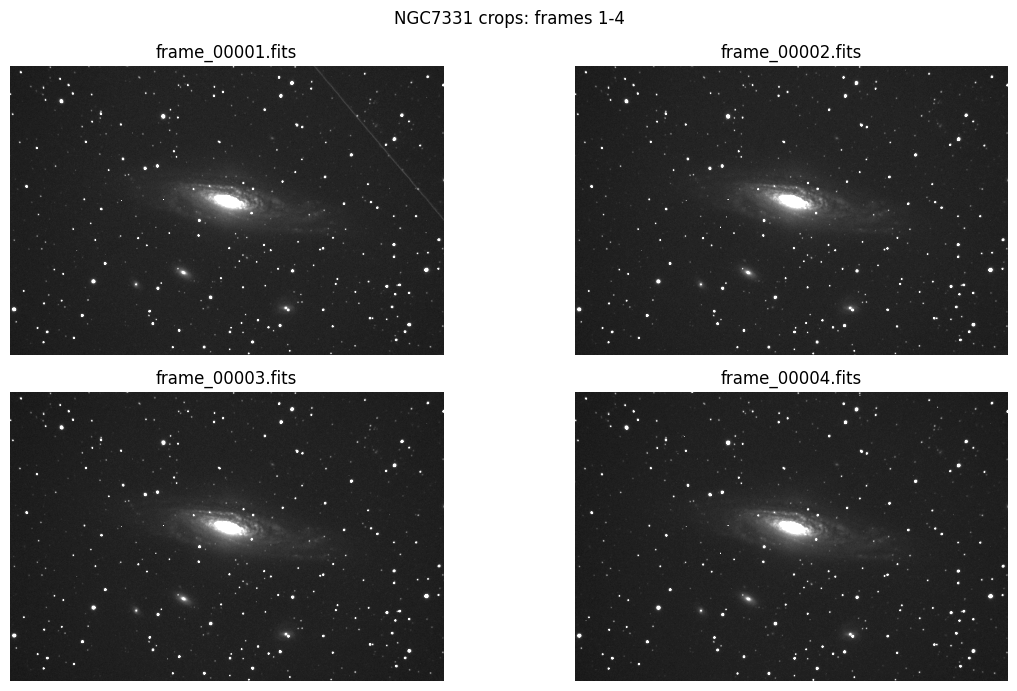

In [11]:
def frame_file(n):
    # Prefer files named with frame_NNNNN pattern; otherwise use first 4 files
    candidate = data_dir / f'frame_{n:05d}.fits'
    if candidate.exists():
        return candidate
    # fallback: use index (n-1) from sorted list if available
    idx = n - 1
    if idx < len(files):
        return files[idx]
    return None


# Ensure repo root is on path
proj_root = Path('..').resolve()
sys.path.insert(0, str(proj_root))
data_dir = proj_root / 'data' / 'ngc7331_crops'
print('Looking for FITS in', data_dir)
if not data_dir.exists():
    raise FileNotFoundError(f'Data directory not found: {data_dir}')
else:
    files = sorted(list(data_dir.glob('*.fits')))

chosen = []
for n in [1, 2, 3, 4]:
    p = frame_file(n)
    if p is None:
        print(f'Frame {n} not found')
    else:
        chosen.append(p)
if not chosen:
    raise FileNotFoundError('No FITS files found in data directory')

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()
for ax, p in zip(axes, chosen):
    with fits.open(str(p)) as hdul:
        arr = hdul[0].data.astype(float)
    # scaling
    vmin, vmax = np.percentile(arr, (1, 99.5))
    ax.imshow(arr, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(p.name)
    ax.axis('off')
# hide any unused axes
for ax in axes[len(chosen):]:
    ax.axis('off')
plt.suptitle('NGC7331 crops: frames 1-4')
plt.tight_layout()
plt.show()

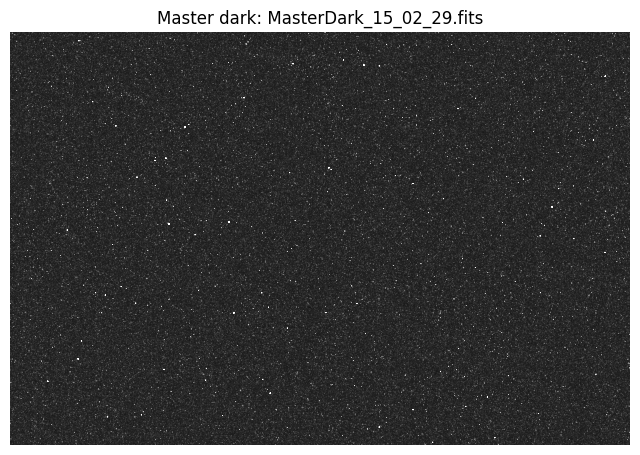

In [12]:
dark_candidates = sorted((data_dir.glob('*master*dark*.fits')) or [])
# also try any dark*.fits if master not found
if not dark_candidates:
    dark_candidates = sorted(list(data_dir.glob('*dark*.fits')))
if not dark_candidates:
    raise FileNotFoundError('No dark frames found in data directory')

# use first dark candidate
p = dark_candidates[0]
with fits.open(str(p)) as hdul:
    arr = hdul[0].data.astype(float)
vmin, vmax = np.percentile(arr, (1, 99))
plt.figure(figsize=(8, 6))
plt.imshow(arr, cmap='gray', vmin=vmin, vmax=vmax)
plt.title('Master dark: ' + p.name)
plt.axis('off')
plt.show()

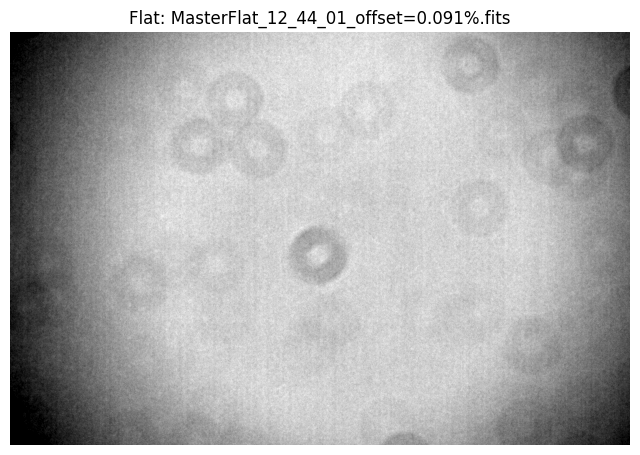

In [14]:
flat_candidates = sorted(list(data_dir.glob('*master*flat*.fits')))
if not flat_candidates:
    flat_candidates = sorted(list(data_dir.glob('*flat*.fits')))[0:8] if list(data_dir.glob('*flat*.fits')) else []
if not flat_candidates:
    raise FileNotFoundError('No flat frames found in data directory')

p = flat_candidates[0]
with fits.open(str(p)) as hdul:
    arr = hdul[0].data.astype(float)
vmin, vmax = np.percentile(arr, (1, 99))
plt.figure(figsize=(8, 6))
plt.imshow(arr, cmap='gray', vmin=vmin, vmax=vmax)
plt.title('Flat: ' + p.name)
plt.axis('off')
plt.show()